## 1. 기존 학습 방식의 한계: 배치 학습 (Batch Learning)

우리가 지금까지 사용해 온 방식은 모델을 처음부터 끝까지 한 번에 훈련하는 배치 학습(Batch Learning) 입니다.

이 방식에는 다음과 같은 **두 가지 문제**가 있습니다.

① 전체 데이터 재훈련 방식

- **과정**
    - 새로운 데이터가 들어올 때마다 기존 데이터 + 신규 데이터를 **모두 합쳐 처음부터 다시 학습**합니다.

- **문제점**
    - 데이터가 누적될수록 **메모리 사용량 증가**, - **CPU/GPU 연산량 폭증**, 결과적으로 **시간과 비용이 계속 증가**
    - 결과적으로 대규모 데이터 환경에서는 학습 효율이 급격히 떨어집니다.

② 데이터 관리 문제

- **과정**
    - 대규모 데이터 환경에서는 저장 공간이나 처리 비용 때문에 일부 오래된 데이터를 제거하고 새로운 데이터를 추가하는 방식을 사용할 수 있습니다.

- **문제점**
    - 과거 데이터가 제고되면 모델이 과거 패턴을 충분히 반영하지 못할 수 있습니다.
    - 그 결과 예측 성능의 안정성이 떨어질 가능성이 있습니다.

---

## 2. 배치 학습의 대안

배치 학습의 한게를 보완하기 위해, 데이터를 나누어 점진적으로 학습하는 방식들이 사용됩니다.

### 온라인 학습 (Online Learning) 또는 점진적 학습(Incremental Learning)

- **개념**
    - 데이터가 하나씩(또는 매우 작은 단위로) 들어올 때마다 모델을 **즉시 업데이트**하는 학습 방식입니다.

- **특징**
    - 메모리 사용량이 적음
    - 전체 데이터를 다시 학습할 필요 없음
    - 최신 데이터의 영향을 빠르게 반영

- **단점**
    - 노이즈 데이터에 민감할 수 있음
    - 학습이 불안정해질 수 있음

---

경사 하강법은 머신러닝과 딥러닝에서 널리 사용되는 **대표적인 온라인 학습 기반 최적화 알고리즘**입니다.

 ---
## 3. 경사 하강법 (Gradient Descent)

경사 하강법은 모델의 **손실 함수** $J(\theta)$ 를 최소화 하기 위해  
손실 함수의 **그래디언트(gradient)** 를 이용하여 파라미터를 반복적으로 업데이트하는  
최적화 기법입니다.

### 기본 아이디어

- 손실 함수의 값이 **줄어드는 방향**, 즉 그래디언트($\nabla J(\theta)$)의 반대 방향으로 이동합니다.
- 이 과정을 여러 번 반복하여 손실 함수를 **최소값**으로 수렴시킵니다.

### 기본 업데이트 식

$$
\theta \larr \theta - \eta\nabla J(\theta)
$$

### 기호 설명

- $\theta$ (세타) : 모델의 파라미터
- $\eta$ (에타) : 학습률(learning rate)
    - 한 번의 업데이트에서 **얼마나 이동할지**를 결정합니다.
- $J(\theta)$ : 손실 함수
- $\nabla$ (델, 나블라) : 그래디언트를 나타내는 미분 연산자
- $\nabla J(\theta)$ :
    - 손실 함수 $J(\theta)$를 파라미터 $\theta$에 대해 미분한 값으로, **그래디언트(gradient)** 라고 합니다.
    - 손실 함수 값이 **가장 빠르게 증가하는 방향**을 나타냅니다.

참고) 기울기(slope)는 하나의 변수에 대한 변화율을 의미합니다.  
그래디언트(gradient)는 여러 변수에 대한 기울기를 모아 놓은 벡터입니다.

따라서 손실을 줄이기 위해 그래디언트의 **반대 방향**으로 파라미터를 업데이트합니다.

$$
-\nabla J(\theta)
$$

---
> 경사 하강법은 손실 함수의 그래티언트 $\nabla J(\theta)$를 계산한 뒤,  
> 그 반대 방향으로 파라미터를 조금씩 이동하며 손실을 최소화 하는 방법입니다.

이해를 위한 문장

손실 함수를 줄이기 위해 파라미터는 **그래디언트의 반대 방향(음의 방향)**으로 이동합니다.  
하지만 한 번에 너무 크게 이동하면 최적의 파라미터 값을 지나칠 수 있습니다.  
따라서 **학습률(learning rate)** 을 사용하여 이동 크기를 조절합니다.

---

## 4. 경사 하강법의 종류

경사 하강법은 **그래디언트를 계산할 때 사용하는 데이터의 양**에 따라 다음과 같이 구분됩니다.

- 딥러닝의 신경망 모델에서는 일반적으로 **미니배치 경사 하강법**이 사용됩니다.

| **종류** | **사용 데이터** | **그래디언트 계산 방식** | **특징** |
| :--- | :--- | :--- | :--- |
| **배치 경사 하강법<br>(Batch Gradient Descent)** | 전체 데이터 | 전체 데이터의 평균 그래디언트 | 안정적이지만 계산 비용이 큼 |
| **확률적 경사 하강법<br>(Stochastic Gradient Descent, SGD)** | 샘플 1개 | 무작위로 선택한 1개 샘플의 그래디언트 | 빠르지만 업데이트가 불안정 |
| **미니배치 경사 하강법<br>(Mini-batch Gradient Descent)** | 소규모 데이터 묶음 | 미니배치 평균 그래디언트 | 속도와 안정성의 균형 |

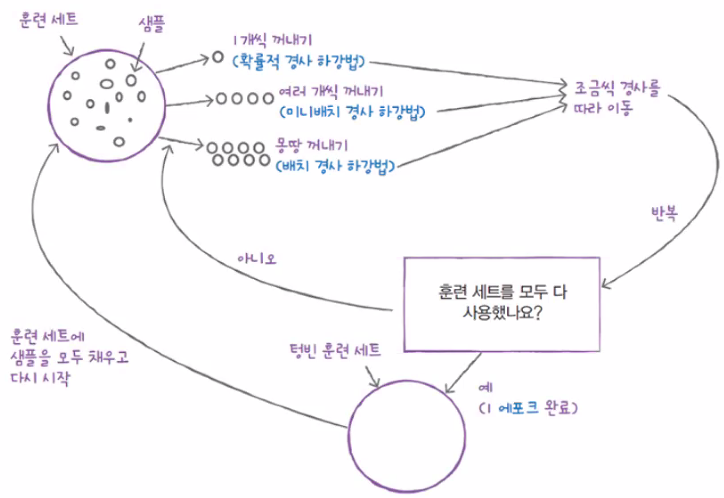

---

### 반복 학습 (Epoch)

- 훈련 데이터 **전체를 한 번씩 모두 사용하면 1 에포크(Epoch)** 가 완료됩니다.
- 이후 데이터를 다시 섞어 **여러 에포크 동안 반복 학습**을 수행합니다.
- 즉, 에포크 수는 **모델이 전체 데이터를 몇 번 반복해서 학습했는지**를 의미합니다.
- 예를 들어 훈련 데이터가 1,000개이고 에포크가 10이면 모델은 총 **10,000번의 샘플 학습**을 수행하게 됩니다.

> 일반적으로 경사 하강법 기반 학습은 수십에서 수백 번 이상의 에포크를 수행하며 학습합니다.

 ---


## SGDClassifier

In [1]:
import pandas as pd

fish = pd.read_csv('data/fish.csv')

In [8]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [10]:
fish_target = fish['Species'].to_numpy()
print(fish_target[:5])

['Bream' 'Bream' 'Bream' 'Bream' 'Bream']


In [11]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [13]:
from sklearn.linear_model import SGDClassifier

In [14]:
# loss='log_loss'는 로지스틱 손실 함수 지정
# max_iter로 epoch 지정
sc = SGDClassifier(loss='log_loss', max_iter=100, random_state=42)

# 가중치, 편향 업데이트
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.865546218487395
0.8


In [15]:
sc.partial_fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.8907563025210085
0.925


 ---
## 에포크와 과대/과소적합

In [18]:
import numpy as np

sc = SGDClassifier(loss='log_loss', random_state=42)

train_score = []
test_score = []

classes = np.unique(train_target)

In [19]:
for _ in range(0, 300):
    sc.partial_fit(train_scaled, train_target, classes=classes)

    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

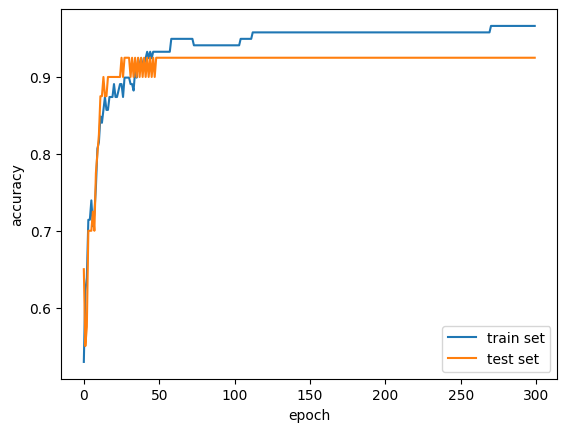

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_score, label='train set')
plt.plot(test_score, label='test set')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

1. 과소적합(Underfitting) 구간 (에포크 약 0 ~ 50)  
에포크 초기에는 훈련 세트와 테스트 세트의 정확도가 모두 낮습니다.
모델이 충분히 학습되지 않아 데이터의 패턴을 제대로 파악하지 못한 상태입니다.

2. 적정 학습 지점 (에포크 약 50 ~ 100)  
현상: 훈련 세트와 테스트 세트의 정확도 격차가 크지 않으면서 두 점수 모두 높은 수준에 도달하는 구간입니다

3. 과대적합(Overfitting) 구간 (에포크 약 100 이후)  
에포크가 진행될수록 훈련 세트의 정확도는 계속 상승하여 1.0에 가까워지는 반면, 테스트 세트의 정확도는 더 이상 오르지 않고 정체되거나 점차 벌어지기 시작합니다.  
모델이 훈련 데이터에 너무 과하게 최적화되어, 새로운 데이터(테스트 세트)에 대해서는 유연하게 대응하지 못하게 된 상태입니다.

In [21]:
# tol 매개변수는 학습을 언제 멈출지 결정하는 '조기 종료(Early Stopping)'를 위한 임곗값 입니다.
# 기본값 tol=1e-3이면 손실 함수의 개선이 0.001 이상 발생하지 않는 상태가
# 여러 번(n_iter_no_change 기본값 5) 반복되면 max_iter 전에 학습 종료합니다.
# tol=None으로 설정하면 조기 종료 없이 max_iter 꽉 채워서 학습합니다.
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925
